
# Do Smart Fill-Level Sensors Actually Reduce Dumpster Overflows?
### A Waste-Management-Industry project applying *Graphical Causal Models* (Chapter 3, Facure — *Causal Inference in Python*)

**The business question:** A waste management company is piloting **IoT fill-level sensors** on
commercial dumpsters. Instead of collecting on a fixed weekly schedule, sensor-equipped bins
report their fill level, letting dispatch **dynamically add an extra pickup** before a bin
overflows. Operations wants to know:

> *Do the sensors actually reduce overflow incidents (bins overflowing, spilling onto sidewalks,
> triggering complaint calls and illegal-dumping magnets) — or does it just look that way because
> sensors were rolled out first at the busiest, highest-risk commercial sites?*

This project reuses the confounding/mediator/collider toolkit from the previous two notebooks,
applied to operations data instead of customer data:

1. **Confounding** — the pilot deliberately targeted high-traffic, high-risk sites first, so a
   naive comparison will be biased — and in a way that could make a genuinely useful program
   look ineffective.
2. **Mediation** — part of the sensor's benefit works *through* a measurable middle step (an
   actual dynamic pickup being triggered). We'll show why controlling for that mediator
   understates the program's true value — the same trap as the banking notebook's budgeting
   habit example.
3. **Selection bias (collider)** — both sensor pilot sites *and* sites with overflow complaints
   get flagged for an operations audit. Restricting the analysis to "audited sites only" reopens
   bias through a collider, just like the survey-response and account-review examples before it.

> As with the previous notebooks, we simulate data with **known potential outcomes** (the
> "godlike powers" trick from the book) so we can check whether each method recovers the truth.


## Step 0 — Setup

In [1]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import graphviz as gr
import statsmodels.formula.api as smf

np.random.seed(21)
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110



## Step 1 — Write down our causal story first

Before looking at any data:

- **`site_traffic`** (0–1: how much commercial waste a site generates — restaurant row vs. a
  quiet office park) drives *both* which sites get sensors first (the pilot prioritized
  high-traffic, high-risk sites) *and* the baseline odds of overflow. Our **confounder**.
- **`sensor_installed`** has:
  - a small **direct effect** on overflow (drivers get an alert and pay closer attention even
    without a formal schedule change), and
  - a larger **indirect / mediated effect**, by triggering **`dynamic_pickup`** (an actual
    extra, unscheduled pickup ahead of an overflow), which is what really prevents the incident.
- **`audited`**: operations audits a subset of sites. Both **`sensor_installed`** (pilot sites
  get monitored for ROI reporting) and **`overflow`** (overflow sites get audited after
  complaints) push a site toward being audited — a **collider**.


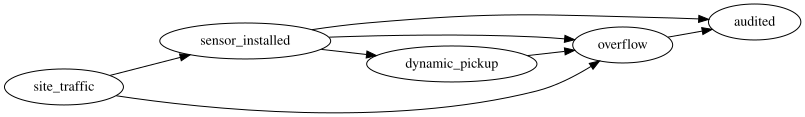

In [2]:

g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.attr('node', shape='ellipse')

g.edge("site_traffic", "sensor_installed")
g.edge("site_traffic", "overflow")
g.edge("sensor_installed", "dynamic_pickup")     # part of the causal story (mediator)
g.edge("dynamic_pickup", "overflow")             # indirect causal path
g.edge("sensor_installed", "overflow")           # direct causal path
g.edge("sensor_installed", "audited")
g.edge("overflow", "audited")                    # collider!

g



**Reading the graph:**

- `site_traffic → sensor_installed` and `site_traffic → overflow`: a **fork** (confounder).
  Because busier, higher-risk sites got sensors *first*, this will tend to make sensor sites
  look worse than they'd otherwise appear — masking the program's real benefit.
- `sensor_installed → dynamic_pickup → overflow`: a **chain**. This is a genuine causal path —
  it's literally *how* the sensor helps — and must stay open.
- `sensor_installed → overflow`: the small direct effect (driver awareness), independent of
  whether an actual extra pickup happened.
- `sensor_installed → audited ← overflow`: an **immorality / collider**. Restricting analysis
  to audited sites opens a noncausal path between `sensor_installed` and `overflow`.



## Step 2 — Simulate data, including *potential outcomes*, so we know the ground truth

We simulate each site's overflow outcome **both** under `sensor_installed = 1` and
`sensor_installed = 0`, using the same underlying noise, so we can compute the *true* average
treatment effect and grade our causal-inference pipeline against it.

**Ground truth we're baking in:**
- Direct effect of having a sensor on overflow probability: **−5 points**
  (`DIRECT_EFFECT = 0.05`)
- Effect of an actual dynamic pickup being triggered on overflow probability: **−22 points**
  (`MEDIATOR_EFFECT = 0.22`)
- Having a sensor increases the probability of a dynamic pickup being triggered by roughly
  **+55 points**

So the **total** effect of the sensor program (direct + mediated) should come out to roughly
`-0.05 - 0.22 * 0.55 ≈ -0.171`, i.e. **about a 17-point reduction in overflow probability**.


In [3]:

n = 25_000
DIRECT_EFFECT = 0.05
MEDIATOR_EFFECT = 0.22

# site_traffic: 0 = low-volume site, 1 = high-volume commercial corridor
site_traffic = np.random.beta(2, 2, n)

# Fixed uniform draws let us build consistent potential outcomes under different
# hypothetical values of `sensor_installed`, same underlying "luck" either way.
u_pickup = np.random.uniform(0, 1, n)
u_overflow = np.random.uniform(0, 1, n)

def pickup_given(sensor_arr):
    p = np.clip(0.10 + 0.55 * sensor_arr + 0.05 * (1 - site_traffic), 0.02, 0.98)
    return (u_pickup < p).astype(int)

def overflow_given(sensor_arr, pickup_arr):
    p = np.clip(
        0.05 + 0.55 * site_traffic - DIRECT_EFFECT * sensor_arr - MEDIATOR_EFFECT * pickup_arr,
        0.01, 0.95
    )
    return (u_overflow < p).astype(int)

# --- Potential outcomes (the "godlike powers" trick) ---
pickup_1, pickup_0 = pickup_given(np.ones(n)), pickup_given(np.zeros(n))
overflow_1 = overflow_given(np.ones(n), pickup_1)
overflow_0 = overflow_given(np.zeros(n), pickup_0)

TRUE_ATE = (overflow_1 - overflow_0).mean()
print(f"TRUE total causal effect of sensor installation on overflow probability: {TRUE_ATE:+.3f}")


TRUE total causal effect of sensor installation on overflow probability: -0.149


Now let's build the **observed** dataset — the only thing a real ops analyst would ever see.

In [4]:

# The pilot targeted busier, higher-risk sites first (this is the confounding mechanism)
p_sensor = 1 / (1 + np.exp(-(4 * site_traffic - 2)))
sensor_installed = np.random.binomial(1, p_sensor)

# Realized mediator and outcome, using the SAME noise draws as the potential outcomes above,
# consistent with the `sensor_installed` value each site actually received
dynamic_pickup = pickup_given(sensor_installed)
overflow = overflow_given(sensor_installed, dynamic_pickup)

# Ops audit: sensor pilot sites and overflow sites are both more likely to get audited
p_audit = 1 / (1 + np.exp(-(-2 + 2.5 * sensor_installed + 3 * overflow)))
audited = np.random.binomial(1, p_audit)

df = pd.DataFrame({
    "site_traffic": site_traffic,
    "sensor_installed": sensor_installed,
    "dynamic_pickup": dynamic_pickup,
    "overflow": overflow,
    "audited": audited,
})

df.head()


,site_traffic,sensor_installed,dynamic_pickup,overflow,audited
0,0.512,0,0,0,0
1,0.869,1,1,0,1
2,0.506,0,0,0,0
3,0.193,0,0,0,0
4,0.703,1,1,1,1



## Step 3 — The naive (wrong) comparison

Operations' first instinct: just compare overflow rates between sensor-equipped and
non-sensor sites.


In [5]:

naive_effect = (
    df.query("sensor_installed == 1")["overflow"].mean()
    - df.query("sensor_installed == 0")["overflow"].mean()
)
print(f"Naive difference in overflow rate: {naive_effect:+.3f}")
print(f"True total causal effect:          {TRUE_ATE:+.3f}")
print(f"Bias in the naive estimate:        {naive_effect - TRUE_ATE:+.3f}")


Naive difference in overflow rate: -0.064
True total causal effect:          -0.149
Bias in the naive estimate:        +0.085



Because sensors were deployed first at the busiest, highest-risk sites, the naive comparison
badly understates how much the sensors actually help — a manager glancing at this raw number
might conclude the (real, measurable) pilot barely moved the needle, and cut the program's
budget. This is the same lesson as the banking notebook: confounding can hide a benefit just as
easily as it can manufacture a fake one.



## Step 4 — Confirm the structure with d-separation


In [6]:

model = nx.DiGraph([
    ("site_traffic", "sensor_installed"),
    ("site_traffic", "overflow"),
    ("sensor_installed", "dynamic_pickup"),
    ("dynamic_pickup", "overflow"),
    ("sensor_installed", "overflow"),
    ("sensor_installed", "audited"),
    ("overflow", "audited"),
])

try:
    def dependent(g, x, y, z=set()):
        return not nx.is_d_separator(g, {x}, {y}, set(z))
except AttributeError:
    def dependent(g, x, y, z=set()):
        return not nx.d_separated(g, {x}, {y}, set(z))

print("sensor_installed / overflow dependent (no conditioning)?             ", dependent(model, "sensor_installed", "overflow"))
print("sensor_installed / overflow dependent, given site_traffic?           ", dependent(model, "sensor_installed", "overflow", {"site_traffic"}))
print("sensor_installed / overflow dependent, given site_traffic + pickup?  ", dependent(model, "sensor_installed", "overflow", {"site_traffic", "dynamic_pickup"}))


sensor_installed / overflow dependent (no conditioning)?              True
sensor_installed / overflow dependent, given site_traffic?            True
sensor_installed / overflow dependent, given site_traffic + pickup?   True



All three come back `True` — there's always at least one open causal path in each case. To
isolate the *noncausal* backdoor path, we again delete the causal edges and re-check, the
"severed graph" trick.


In [7]:

# Delete BOTH causal edges (direct AND mediated) to isolate purely noncausal paths
severed = nx.DiGraph([
    ("site_traffic", "sensor_installed"),
    ("site_traffic", "overflow"),
    ("sensor_installed", "dynamic_pickup"),
    # ("dynamic_pickup", "overflow"),      <-- mediated causal edge removed
    # ("sensor_installed", "overflow"),    <-- direct causal edge removed
    ("sensor_installed", "audited"),
    ("overflow", "audited"),
])

print("With BOTH causal edges removed:")
print("  Still dependent, no adjustment?               ",
      dependent(severed, "sensor_installed", "overflow"), " <- backdoor path via site_traffic (bias)")
print("  Still dependent, given site_traffic?           ",
      dependent(severed, "sensor_installed", "overflow", {"site_traffic"}), " <- adjusting for the confounder closes it")


With BOTH causal edges removed:
  Still dependent, no adjustment?                True  <- backdoor path via site_traffic (bias)
  Still dependent, given site_traffic?            False  <- adjusting for the confounder closes it



## Step 5 — Backdoor adjustment: recover the TOTAL effect

To get the sensor program's **total** effect (direct alertness + the actual triggered pickups),
we adjust for the confounder `site_traffic` **only** — we must leave the mediator
(`dynamic_pickup`) alone, since `sensor_installed → dynamic_pickup → overflow` is a genuine
causal path we want to keep open.


In [8]:

total_effect_model = smf.ols("overflow ~ sensor_installed + site_traffic", data=df).fit()
print(total_effect_model.summary().tables[1])

adjusted_total_effect = total_effect_model.params["sensor_installed"]
print(f"\nBackdoor-adjusted TOTAL effect (correct):  {adjusted_total_effect:+.3f}")
print(f"True total causal effect:                   {TRUE_ATE:+.3f}")


                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0465      0.006      7.470      0.000       0.034       0.059
sensor_installed    -0.1507      0.005    -27.412      0.000      -0.161      -0.140
site_traffic         0.4988      0.012     40.611      0.000       0.475       0.523

Backdoor-adjusted TOTAL effect (correct):  -0.151
True total causal effect:                   -0.149



Close match — adjusting for `site_traffic` closes the confounding backdoor path and recovers
(approximately) the sensor program's true total effect.



## Step 6 — The trap: conditioning on the mediator

An analyst might reason: *"I want to isolate the pure 'sensor awareness' effect, separate from
whatever pickups actually got triggered."* So they add `dynamic_pickup` as a control variable.

This is the same mistake as the banking notebook's budgeting-habit example: `dynamic_pickup` is
a **mediator**, not a confounder. Controlling for it blocks the very mechanism through which the
sensors mostly work, leaving only the **direct** effect — and badly understating the program's
real value.


In [9]:

direct_only_model = smf.ols("overflow ~ sensor_installed + site_traffic + dynamic_pickup", data=df).fit()
print(direct_only_model.summary().tables[1])

direct_only_effect = direct_only_model.params["sensor_installed"]
print(f"\n'Direct-only' effect (mediator wrongly controlled for): {direct_only_effect:+.3f}")
print(f"True DIRECT effect we baked into the simulation:          {-DIRECT_EFFECT:+.3f}")
print(f"True TOTAL effect (what operations actually cares about): {TRUE_ATE:+.3f}")


                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0801      0.006     12.998      0.000       0.068       0.092
sensor_installed    -0.0350      0.006     -5.549      0.000      -0.047      -0.023
site_traffic         0.4856      0.012     40.467      0.000       0.462       0.509
dynamic_pickup      -0.2109      0.006    -34.911      0.000      -0.223      -0.199

'Direct-only' effect (mediator wrongly controlled for): -0.035
True DIRECT effect we baked into the simulation:          -0.050
True TOTAL effect (what operations actually cares about): -0.149



The "direct-only" estimate lands close to the true **direct** effect (−0.05) — **not** the total
effect (roughly −0.17) operations actually cares about. If the real question is *"should we
scale sensors to every site?"*, they want the total effect, dynamic pickups included. Controlling
for the mediator here would make a highly effective program look almost negligible.

> **Rule of thumb from the chapter:** only condition on variables that lie *outside* the causal
> path you're trying to measure. A mediator is *part of* that path — measuring it is fine
> (it's useful for understanding *mechanism*), but conditioning on it while estimating the
> *total* effect is not.



## Step 7 — The other trap: conditioning on the collider (selection bias)

Now suppose an analyst, wanting "verified, ground-truthed" data, restricts the study to sites
that ops has already **audited** — reasoning that audited sites have manually confirmed fill
data. But `audited` is a **collider** on the path `sensor_installed → audited ← overflow`.


In [10]:

print("Audit rate among sensor sites:      ", f"{df.query('sensor_installed==1')['audited'].mean():.2%}")
print("Audit rate among non-sensor sites:  ", f"{df.query('sensor_installed==0')['audited'].mean():.2%}")

print("\nDependence check in the (fully) severed graph, conditioning on site_traffic AND audited:")
severed_full = nx.DiGraph([
    ("site_traffic", "sensor_installed"),
    ("site_traffic", "overflow"),
    ("sensor_installed", "dynamic_pickup"),
    ("sensor_installed", "audited"),
    ("overflow", "audited"),
])
print(" ", dependent(severed_full, "sensor_installed", "overflow", {"site_traffic", "audited"}),
      " <- True means a bias-only path was opened by conditioning on the collider")


Audit rate among sensor sites:       68.76%
Audit rate among non-sensor sites:   27.10%

Dependence check in the (fully) severed graph, conditioning on site_traffic AND audited:
  True  <- True means a bias-only path was opened by conditioning on the collider


In [11]:

audited_only = df.query("audited == 1")

biased_model = smf.ols("overflow ~ sensor_installed + site_traffic", data=audited_only).fit()
biased_effect = biased_model.params["sensor_installed"]

print(f"'Audited-only' adjusted effect (selection-biased): {biased_effect:+.3f}")
print(f"Full-sample adjusted TOTAL effect (Step 5, correct): {adjusted_total_effect:+.3f}")
print(f"True total causal effect:                            {TRUE_ATE:+.3f}")


'Audited-only' adjusted effect (selection-biased): -0.493
Full-sample adjusted TOTAL effect (Step 5, correct): -0.151
True total causal effect:                            -0.149



Restricting to audited sites distorts the estimate badly — because both sensor status and
overflow outcome independently push a site toward being audited, comparing sensor vs.
non-sensor *within* the audited subgroup compares systematically different populations. Just
like the previous notebooks: **this bias would persist even under a fully randomized sensor
rollout**, since it comes from how the *data was filtered*, not from how the *treatment was
assigned*.



## Step 8 — Putting it all together


In [12]:

print("Comparison of all estimates:\n")
print(f"{'Naive (no adjustment)':45s}: {naive_effect:+.3f}")
print(f"{'Backdoor-adjusted TOTAL effect (correct)':45s}: {adjusted_total_effect:+.3f}")
print(f"{'Mediator wrongly controlled for (direct only)':45s}: {direct_only_effect:+.3f}")
print(f"{'Collider wrongly controlled for (audited-only)':45s}: {biased_effect:+.3f}")
print(f"{'TRUE total causal effect (ground truth)':45s}: {TRUE_ATE:+.3f}")


Comparison of all estimates:

Naive (no adjustment)                        : -0.064
Backdoor-adjusted TOTAL effect (correct)     : -0.151
Mediator wrongly controlled for (direct only): -0.035
Collider wrongly controlled for (audited-only): -0.493
TRUE total causal effect (ground truth)      : -0.149


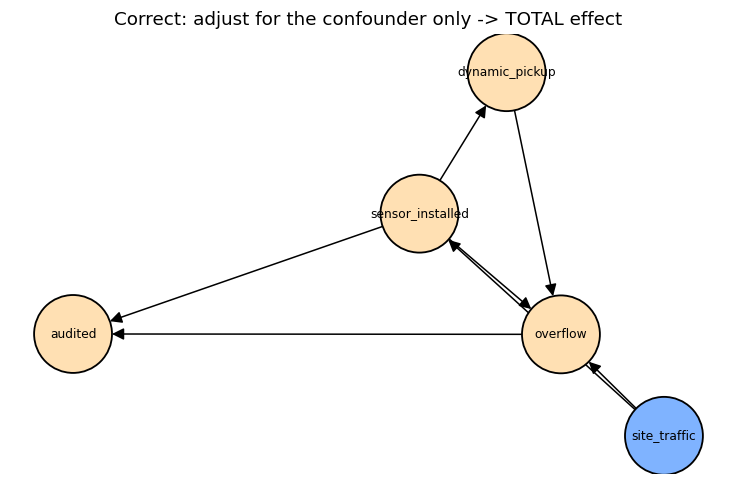

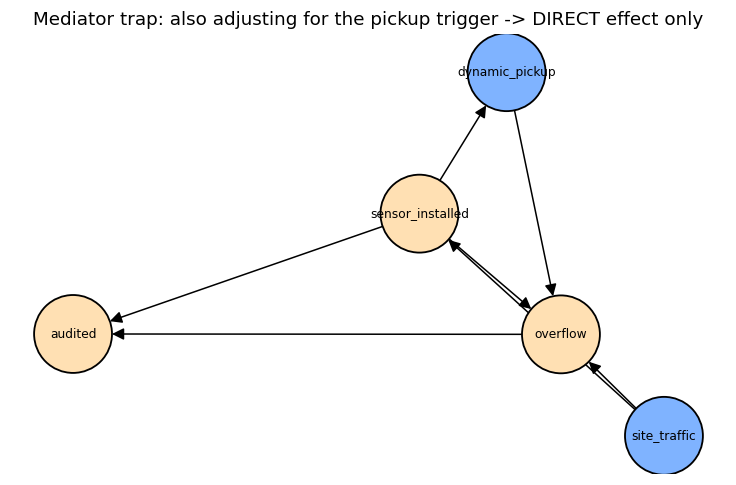

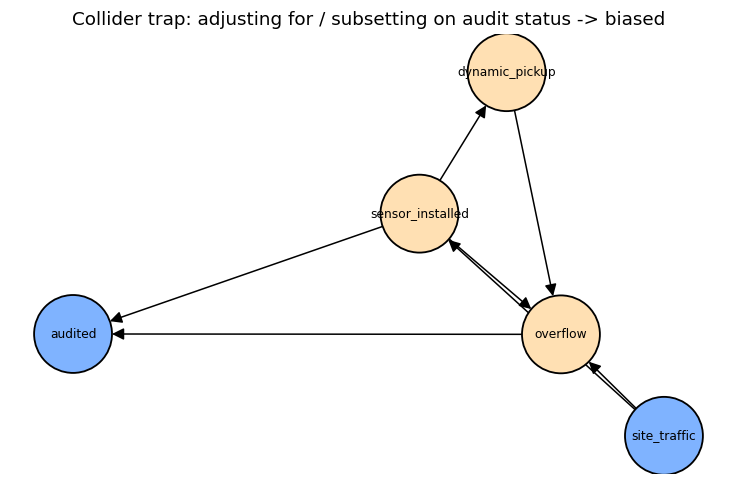

In [13]:

def draw_dag(edges, conditioned=set(), title=""):
    G = nx.DiGraph(edges)
    pos = nx.spring_layout(G, seed=13, k=1.3)
    colors = ["#7fb3ff" if n in conditioned else "#ffe0b3" for n in G.nodes()]
    plt.figure(figsize=(6.5, 4))
    nx.draw(
        G, pos, with_labels=True, node_color=colors, node_size=2600,
        font_size=8, arrowsize=16, edgecolors="black", linewidths=1.2
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

full_edges = [
    ("site_traffic", "sensor_installed"),
    ("site_traffic", "overflow"),
    ("sensor_installed", "dynamic_pickup"),
    ("dynamic_pickup", "overflow"),
    ("sensor_installed", "overflow"),
    ("sensor_installed", "audited"),
    ("overflow", "audited"),
]

draw_dag(full_edges, conditioned={"site_traffic"},
         title="Correct: adjust for the confounder only -> TOTAL effect")
draw_dag(full_edges, conditioned={"site_traffic", "dynamic_pickup"},
         title="Mediator trap: also adjusting for the pickup trigger -> DIRECT effect only")
draw_dag(full_edges, conditioned={"site_traffic", "audited"},
         title="Collider trap: adjusting for / subsetting on audit status -> biased")



## Key takeaways

1. **Confounding bias can hide real operational gains, not just fabricate fake ones.** Because
   the pilot deliberately targeted the highest-risk sites, the naive comparison made an
   effective sensor program look almost useless. Always ask *how sites/customers were selected
   for treatment* before trusting a raw before/after or treated/untreated comparison.
2. **Mechanism variables (mediators) are not confounders.** `dynamic_pickup` is part of *how*
   the sensors work, not a pre-existing cause of both sensor placement and overflow risk.
   Controlling for it answers "what's the sensor's effect *beyond* triggering extra pickups?" —
   a legitimate but much narrower question than "should we fund this program?"
3. **Restricting to an audited/inspected/verified subset is a collider trap.** It's tempting
   because audited data often feels more trustworthy, but if both the treatment and the outcome
   independently drive audit selection, you've reopened a purely noncausal path — and no amount
   of additional data volume fixes it.
4. **Simulating potential outcomes** lets you stress-test a causal-inference pipeline with a
   known answer before trusting it on real operations data — bake in an effect, then verify each
   adjustment strategy recovers (or fails to recover) it.

### Suggested extensions
- Replace the linear-probability regressions with **logistic regression**, and report results as
  odds ratios — more standard for incident-rate modeling.
- Add a genuinely **unobserved confounder** (e.g., "site manager engagement/diligence") driving
  both sensor adoption enthusiasm and overflow prevention behavior, then explore **surrogate
  confounders** (like historical missed-pickup complaint counts) as a partial fix.
- Extend to a **route-level, multi-period panel** (weekly overflow counts per site over a year)
  and use difference-in-differences or a fixed-effects panel model to control for
  time-invariant site characteristics — a very common real-world setup in fleet/route
  optimization analytics.
- Model **contamination rate** (recyclables contaminated with trash) as a second outcome and
  check whether the sensor's causal story (direct vs. mediated) looks different for that metric.
